In [2]:
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from src.config import file_config

df_results = pd.read_csv(f"{file_config.results_dir}/predictions_rolling_pretrained_ensemble.csv")
print(df_results.head())


   actual  tft_pred  tft_lower  tft_upper  corrected_median  corrected_upper  \
0     0.0       0.0        0.0   0.020628               0.0              0.0   
1     0.0       0.0        0.0   0.021101               0.0              0.0   
2     0.0       0.0        0.0   0.019691               0.0              0.0   
3     0.0       0.0        0.0   0.020213               0.0              0.0   
4     0.0       0.0        0.0   0.020306               0.0              0.0   

   corrected_lower  correction  daylight        date                 time  \
0              0.0    0.008732         0  2023-01-11  2023-01-11 00:00:00   
1              0.0   -0.028669         0  2023-01-11  2023-01-11 01:00:00   
2              0.0   -0.031442         0  2023-01-11  2023-01-11 02:00:00   
3              0.0    0.002645         0  2023-01-11  2023-01-11 03:00:00   
4              0.0   -0.028649         0  2023-01-11  2023-01-11 04:00:00   

   naive  arima_pred  
0    0.0    0.000013  
1    0.0  

python(77954) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Residual error variance: 0.0225
ARIMA error variance:    0.0207
Residual: bias=0.0003 variance=0.0225 RMSE=0.1501
ARIMA:    bias=0.0586 variance=0.0207 RMSE=0.1553
Residual: p95=0.2953 p99=0.4022 excess_kurtosis=0.1825
ARIMA:    p95=0.3173 p99=0.4491 excess_kurtosis=1.4007


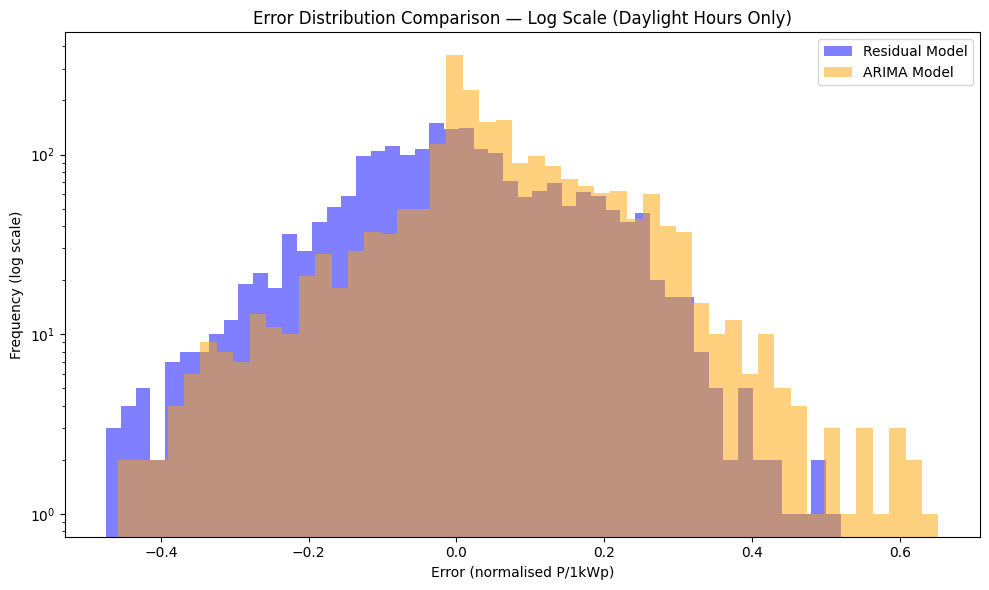

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kurtosis
# filter to daylight hours only
daylight_mask = df_results["daylight"] == 1

residual_errors = (
    df_results.loc[daylight_mask, "actual"] - 
    df_results.loc[daylight_mask, "corrected_median"]
)
arima_errors = (
    df_results.loc[daylight_mask, "actual"] - 
    df_results.loc[daylight_mask, "arima_pred"]
)

plt.figure(figsize=(10, 6))
plt.hist(residual_errors, bins=50, alpha=0.5, color="blue", label="Residual Model")
plt.hist(arima_errors, bins=50, alpha=0.5, color="orange", label="ARIMA Model")
plt.yscale("log")
plt.xlabel("Error (normalised P/1kWp)")
plt.ylabel("Frequency (log scale)")
plt.title("Error Distribution Comparison — Log Scale (Daylight Hours Only)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{file_config.results_dir}/error_distribution_daylight_log.png", dpi=300)
mask = df_results["daylight"] == 1

res_var   = (df_results.loc[mask, "actual"] - df_results.loc[mask, "corrected_median"]).var()
arima_var = (df_results.loc[mask, "actual"] - df_results.loc[mask, "arima_pred"]).var()

print(f"Residual error variance: {res_var:.4f}")
print(f"ARIMA error variance:    {arima_var:.4f}")
res_bias   = (df_results.loc[mask, "actual"] - df_results.loc[mask, "corrected_median"]).mean()
arima_bias = (df_results.loc[mask, "actual"] - df_results.loc[mask, "arima_pred"]).mean()

res_rmse   = np.sqrt(((df_results.loc[mask, "actual"] - df_results.loc[mask, "corrected_median"])**2).mean())
arima_rmse = np.sqrt(((df_results.loc[mask, "actual"] - df_results.loc[mask, "arima_pred"])**2).mean())

print(f"Residual: bias={res_bias:.4f} variance={res_var:.4f} RMSE={res_rmse:.4f}")
print(f"ARIMA:    bias={arima_bias:.4f} variance={arima_var:.4f} RMSE={arima_rmse:.4f}")

res_p95, res_p99   = np.percentile(np.abs(residual_errors), [95, 99])
arima_p95, arima_p99 = np.percentile(np.abs(arima_errors), [95, 99])

res_kurt   = kurtosis(residual_errors)      # excess kurtosis, normal = 0
arima_kurt = kurtosis(arima_errors)

print(f"Residual: p95={res_p95:.4f} p99={res_p99:.4f} excess_kurtosis={res_kurt:.4f}")
print(f"ARIMA:    p95={arima_p95:.4f} p99={arima_p99:.4f} excess_kurtosis={arima_kurt:.4f}")

Residual error variance: 0.0150
ARIMA error variance:    0.0140
Residual: bias=-0.0055 variance=0.0150 RMSE=0.1226
ARIMA:    bias=0.0466 variance=0.0140 RMSE=0.1272


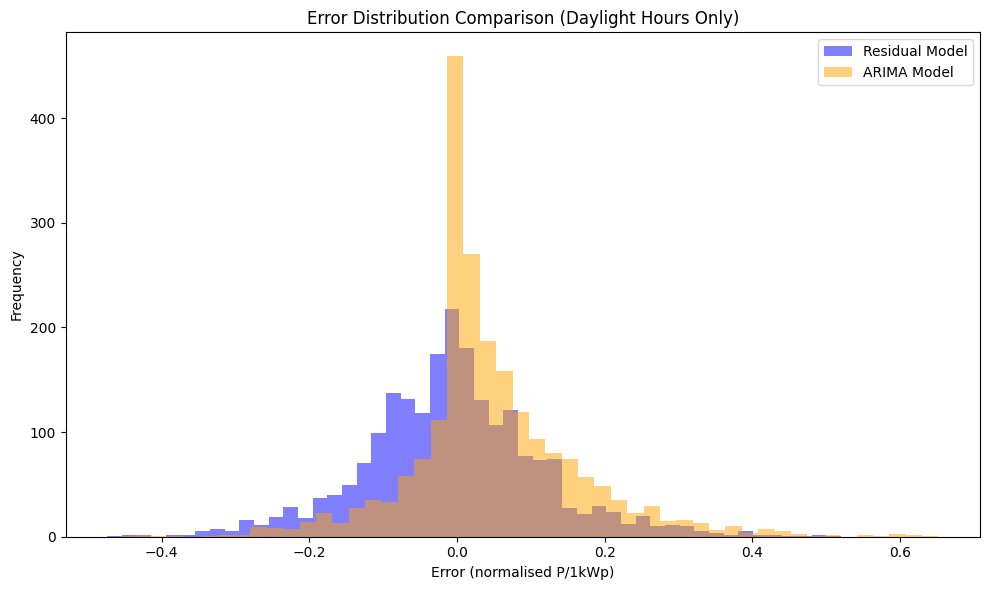

In [16]:
import matplotlib.pyplot as plt
import numpy as np
# filter to daylight hours only
results  = pd.read_csv(f"{file_config.results_dir}/predictions_rolling_pretrained_shaded_ensemble.csv")
daylight_mask = results["daylight"] == 1

residual_errors = (
    results.loc[daylight_mask, "actual"] - 
    results.loc[daylight_mask, "corrected_median"]
)
arima_errors = (
    results.loc[daylight_mask, "actual"] - 
    results.loc[daylight_mask, "arima_pred"]
)

plt.figure(figsize=(10, 6))
plt.hist(residual_errors, bins=50, alpha=0.5, 
         color="blue", label="Residual Model")
plt.hist(arima_errors, bins=50, alpha=0.5, 
         color="orange", label="ARIMA Model")
plt.xlabel("Error (normalised P/1kWp)")
plt.ylabel("Frequency")
plt.title("Error Distribution Comparison (Daylight Hours Only)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{file_config.results_dir}/error_distribution_daylight_shaded.png", dpi=300)

mask = results["daylight"] == 1

res_var   = (results.loc[mask, "actual"] - results.loc[mask, "corrected_median"]).var()
arima_var = (results.loc[mask, "actual"] - results.loc[mask, "arima_pred"]).var()

print(f"Residual error variance: {res_var:.4f}")
print(f"ARIMA error variance:    {arima_var:.4f}")

res_bias   = (results.loc[mask, "actual"] - results.loc[mask, "corrected_median"]).mean()
arima_bias = (results.loc[mask, "actual"] - results.loc[mask, "arima_pred"]).mean()

res_rmse   = np.sqrt(((results.loc[mask, "actual"] - results.loc[mask, "corrected_median"])**2).mean())
arima_rmse = np.sqrt(((results.loc[mask, "actual"] - results.loc[mask, "arima_pred"])**2).mean())

print(f"Residual: bias={res_bias:.4f} variance={0.0150:.4f} RMSE={res_rmse:.4f}")
print(f"ARIMA:    bias={arima_bias:.4f} variance={0.0140:.4f} RMSE={arima_rmse:.4f}")

Residual error variance: 0.0208
ARIMA error variance:    0.0191
Residual: bias=-0.0012 variance=0.0150 RMSE=0.1441
ARIMA:    bias=0.0550 variance=0.0140 RMSE=0.1488


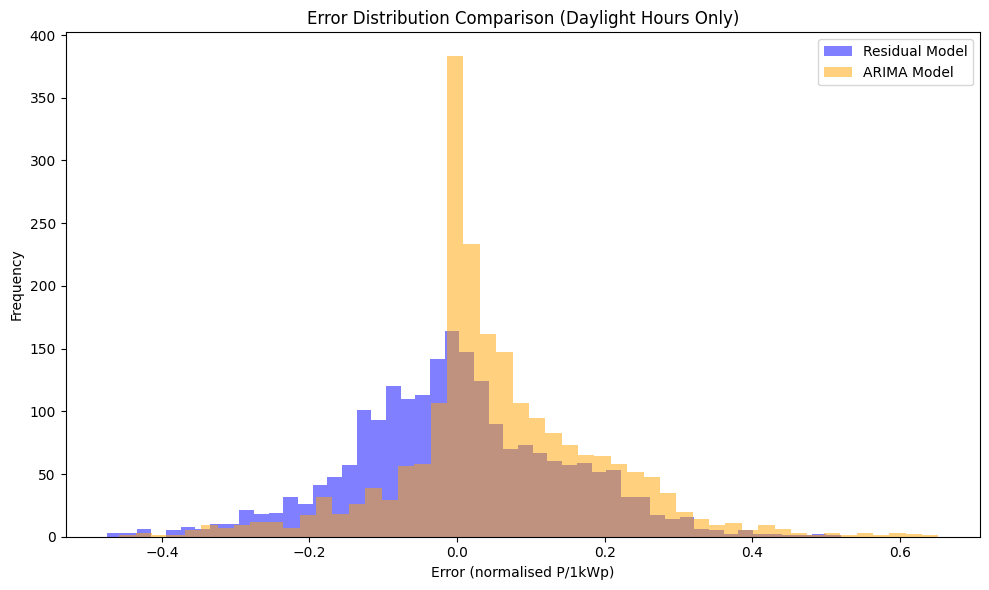

In [17]:
import matplotlib.pyplot as plt
# filter to daylight hours only
results  = pd.read_csv(f"{file_config.results_dir}/predictions_rolling_pretrained_drifted_ensemble.csv")
daylight_mask = results["daylight"] == 1

residual_errors = (
    results.loc[daylight_mask, "actual"] - 
    results.loc[daylight_mask, "corrected_median"]
)
arima_errors = (
    results.loc[daylight_mask, "actual"] - 
    results.loc[daylight_mask, "arima_pred"]
)

plt.figure(figsize=(10, 6))
plt.hist(residual_errors, bins=50, alpha=0.5, 
         color="blue", label="Residual Model")
plt.hist(arima_errors, bins=50, alpha=0.5, 
         color="orange", label="ARIMA Model")
plt.xlabel("Error (normalised P/1kWp)")
plt.ylabel("Frequency")
plt.title("Error Distribution Comparison (Daylight Hours Only)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{file_config.results_dir}/error_distribution_daylight_shaded.png", dpi=300)

mask = results["daylight"] == 1

res_var   = (results.loc[mask, "actual"] - results.loc[mask, "corrected_median"]).var()
arima_var = (results.loc[mask, "actual"] - results.loc[mask, "arima_pred"]).var()

print(f"Residual error variance: {res_var:.4f}")
print(f"ARIMA error variance:    {arima_var:.4f}")
res_bias   = (results.loc[mask, "actual"] - results.loc[mask, "corrected_median"]).mean()
arima_bias = (results.loc[mask, "actual"] - results.loc[mask, "arima_pred"]).mean()

res_rmse   = np.sqrt(((results.loc[mask, "actual"] - results.loc[mask, "corrected_median"])**2).mean())
arima_rmse = np.sqrt(((results.loc[mask, "actual"] - results.loc[mask, "arima_pred"])**2).mean())

print(f"Residual: bias={res_bias:.4f} variance={0.0150:.4f} RMSE={res_rmse:.4f}")
print(f"ARIMA:    bias={arima_bias:.4f} variance={0.0140:.4f} RMSE={arima_rmse:.4f}")

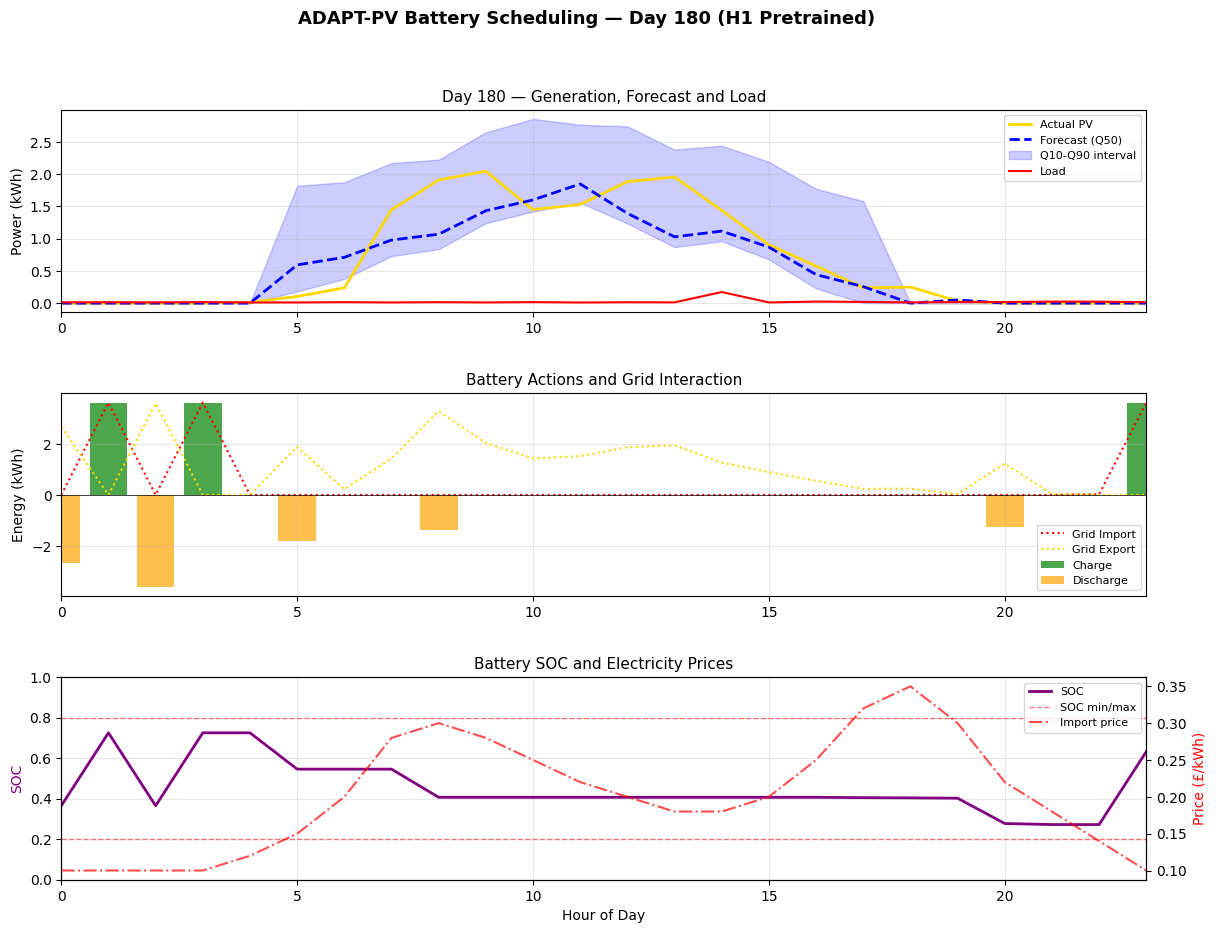

In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# load your saved CSV
df = pd.read_csv(f"{file_config.results_dir}/control_tft_residual_pretrained_h1.csv")

# pick a day to visualise — try a summer day (day 180 = late June)
day = 180
mask = df["day"] == day
day_df = df[mask].reset_index(drop=True)

hours = day_df["hour"]

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 1, hspace=0.4)

# Panel 1 — Generation and Load
ax1 = fig.add_subplot(gs[0])
ax1.plot(hours, day_df["actual_pv"],       
         color="gold", linewidth=2, label="Actual PV")
ax1.plot(hours, day_df["forecast_median"], 
         color="blue", linewidth=2, linestyle="--", label="Forecast (Q50)")
ax1.fill_between(hours, 
                  day_df["forecast_lower"],
                  day_df["forecast_upper"],
                  alpha=0.2, color="blue", label="Q10-Q90 interval")
ax1.plot(hours, day_df["load"],            
         color="red", linewidth=1.5, label="Load")
ax1.set_ylabel("Power (kWh)", fontsize=10)
ax1.set_title(f"Day {day} — Generation, Forecast and Load", fontsize=11)
ax1.legend(fontsize=8)
ax1.set_xlim(0, 23)
ax1.grid(alpha=0.3)

# Panel 2 — Battery actions
ax2 = fig.add_subplot(gs[1])
ax2.bar(hours, day_df["charge"],    
        color="green", alpha=0.7, label="Charge")
ax2.bar(hours, -day_df["discharge"],
        color="orange", alpha=0.7, label="Discharge")
ax2.plot(hours, day_df["actual_import"], 
         color="red", linewidth=1.5, 
         linestyle=":", label="Grid Import")
ax2.plot(hours, day_df["actual_export"], 
         color="gold", linewidth=1.5, 
         linestyle=":", label="Grid Export")
ax2.set_ylabel("Energy (kWh)", fontsize=10)
ax2.set_title("Battery Actions and Grid Interaction", fontsize=11)
ax2.legend(fontsize=8)
ax2.set_xlim(0, 23)
ax2.axhline(y=0, color="black", linewidth=0.5)
ax2.grid(alpha=0.3)

# Panel 3 — SOC and prices
ax3 = fig.add_subplot(gs[2])
ax3_twin = ax3.twinx()

ax3.plot(hours, day_df["soc_next"],    
         color="purple", linewidth=2, label="SOC")
ax3.axhline(y=0.2, color="red", linestyle="--", 
            alpha=0.5, linewidth=1, label="SOC min/max")
ax3.axhline(y=0.8, color="red", linestyle="--", alpha=0.5, linewidth=1)
ax3.set_ylabel("SOC", fontsize=10, color="purple")
ax3.set_ylim(0, 1)

ax3_twin.plot(hours, day_df["import_price"], 
              color="red", linewidth=1.5, 
              linestyle="-.", alpha=0.7, label="Import price")
ax3_twin.set_ylabel("Price (£/kWh)", fontsize=10, color="red")

ax3.set_xlabel("Hour of Day", fontsize=10)
ax3.set_title("Battery SOC and Electricity Prices", fontsize=11)
ax3.set_xlim(0, 23)
ax3.grid(alpha=0.3)

# combine legends
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle(f"ADAPT-PV Battery Scheduling — Day {day} (H1 Pretrained)", 
             fontsize=13, fontweight='bold')
plt.savefig(f"{file_config.results_dir}/scheduling_day_{day}_tft_residual.png", 
            dpi=300, bbox_inches='tight')
plt.show()

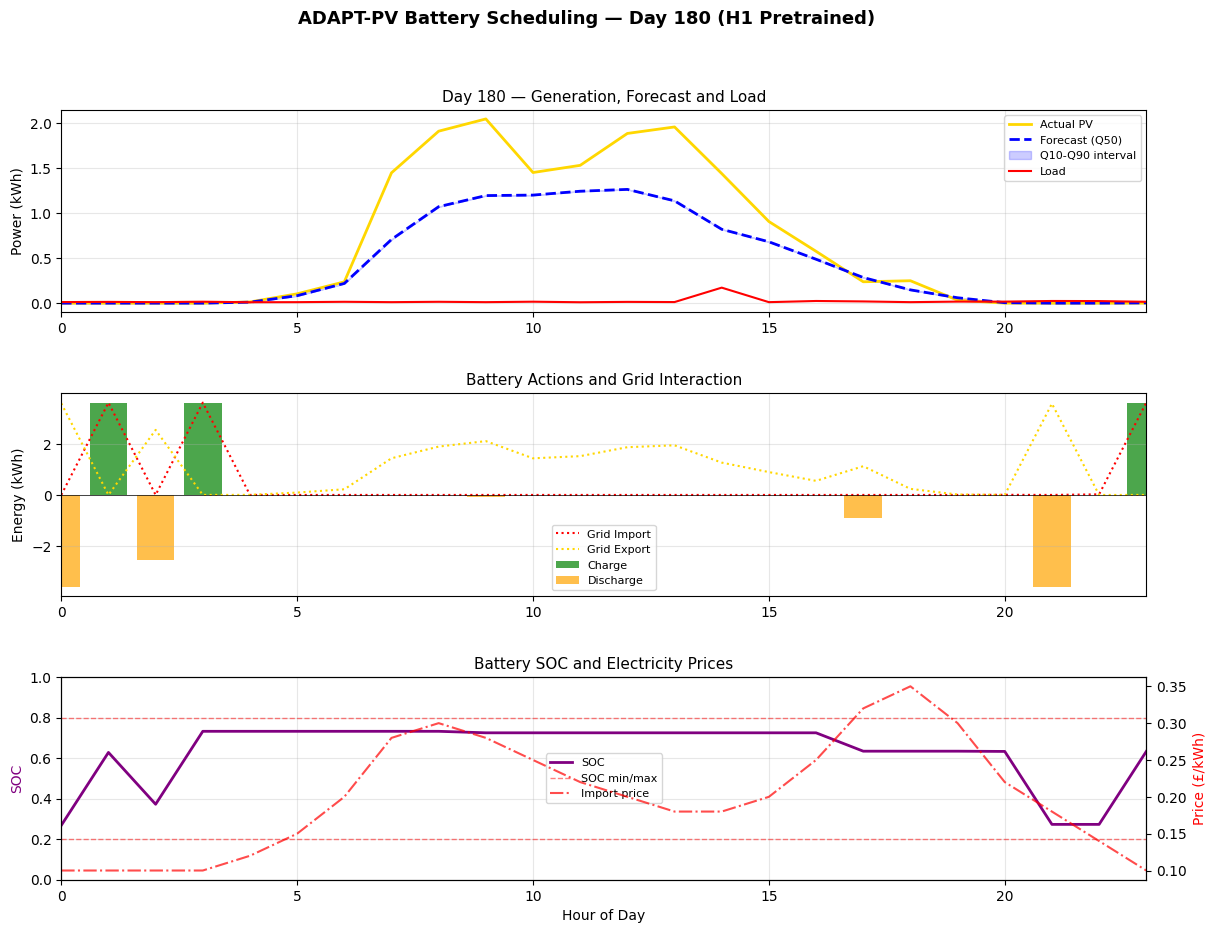

In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# load your saved CSV
df = pd.read_csv(f"{file_config.results_dir}/control_arima_pretrained_h1.csv")

# pick a day to visualise — try a summer day (day 180 = late June)
day = 180
mask = df["day"] == day
day_df = df[mask].reset_index(drop=True)

hours = day_df["hour"]

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 1, hspace=0.4)

# Panel 1 — Generation and Load
ax1 = fig.add_subplot(gs[0])
ax1.plot(hours, day_df["actual_pv"],       
         color="gold", linewidth=2, label="Actual PV")
ax1.plot(hours, day_df["forecast_median"], 
         color="blue", linewidth=2, linestyle="--", label="Forecast (Q50)")
ax1.fill_between(hours, 
                  day_df["forecast_lower"],
                  day_df["forecast_upper"],
                  alpha=0.2, color="blue", label="Q10-Q90 interval")
ax1.plot(hours, day_df["load"],            
         color="red", linewidth=1.5, label="Load")
ax1.set_ylabel("Power (kWh)", fontsize=10)
ax1.set_title(f"Day {day} — Generation, Forecast and Load", fontsize=11)
ax1.legend(fontsize=8)
ax1.set_xlim(0, 23)
ax1.grid(alpha=0.3)

# Panel 2 — Battery actions
ax2 = fig.add_subplot(gs[1])
ax2.bar(hours, day_df["charge"],    
        color="green", alpha=0.7, label="Charge")
ax2.bar(hours, -day_df["discharge"],
        color="orange", alpha=0.7, label="Discharge")
ax2.plot(hours, day_df["actual_import"], 
         color="red", linewidth=1.5, 
         linestyle=":", label="Grid Import")
ax2.plot(hours, day_df["actual_export"], 
         color="gold", linewidth=1.5, 
         linestyle=":", label="Grid Export")
ax2.set_ylabel("Energy (kWh)", fontsize=10)
ax2.set_title("Battery Actions and Grid Interaction", fontsize=11)
ax2.legend(fontsize=8)
ax2.set_xlim(0, 23)
ax2.axhline(y=0, color="black", linewidth=0.5)
ax2.grid(alpha=0.3)

# Panel 3 — SOC and prices
ax3 = fig.add_subplot(gs[2])
ax3_twin = ax3.twinx()

ax3.plot(hours, day_df["soc_next"],    
         color="purple", linewidth=2, label="SOC")
ax3.axhline(y=0.2, color="red", linestyle="--", 
            alpha=0.5, linewidth=1, label="SOC min/max")
ax3.axhline(y=0.8, color="red", linestyle="--", alpha=0.5, linewidth=1)
ax3.set_ylabel("SOC", fontsize=10, color="purple")
ax3.set_ylim(0, 1)

ax3_twin.plot(hours, day_df["import_price"], 
              color="red", linewidth=1.5, 
              linestyle="-.", alpha=0.7, label="Import price")
ax3_twin.set_ylabel("Price (£/kWh)", fontsize=10, color="red")

ax3.set_xlabel("Hour of Day", fontsize=10)
ax3.set_title("Battery SOC and Electricity Prices", fontsize=11)
ax3.set_xlim(0, 23)
ax3.grid(alpha=0.3)

# combine legends
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle(f"ADAPT-PV Battery Scheduling — Day {day} (H1 Pretrained)", 
             fontsize=13, fontweight='bold')
plt.savefig(f"{file_config.results_dir}/scheduling_day_{day}_arima.png", 
            dpi=300, bbox_inches='tight')
plt.show()